In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr

In [2]:
df=pd.read_csv('academic Stress level.csv')

In [4]:
df.head(5)

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   Timestamp                                                            140 non-null    object
 1   Your Academic Stage                                                  140 non-null    object
 2   Peer pressure                                                        140 non-null    int64 
 3   Academic pressure from your home                                     140 non-null    int64 
 4   Study Environment                                                    139 non-null    object
 5   What coping strategy you use as a student?                           140 non-null    object
 6   Do you have any bad habits like smoking, drinking on a daily basis?  140 non-null    object
 7   What would you rat

In [7]:
df.isnull().sum()

,0
Timestamp,0
Your Academic Stage,0
Peer pressure,0
Academic pressure from your home,0
Study Environment,1
What coping strategy you use as a student?,0
"Do you have any bad habits like smoking, drinking on a daily basis?",0
What would you rate the academic competition in your student life,0
Rate your academic stress index,0


In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

,0
Timestamp,0
Your Academic Stage,0
Peer pressure,0
Academic pressure from your home,0
Study Environment,0
What coping strategy you use as a student?,0
"Do you have any bad habits like smoking, drinking on a daily basis?",0
What would you rate the academic competition in your student life,0
Rate your academic stress index,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['Peer pressure'] = pd.to_numeric(df['Peer pressure'], errors='coerce')
df['Academic pressure from your home'] = pd.to_numeric(df['Academic pressure from your home'], errors='coerce')
df['Rate your academic stress index '] = pd.to_numeric(df['Rate your academic stress index '], errors='coerce')



In [13]:
print(df.groupby("Your Academic Stage")['Rate your academic stress index '].mean())


Your Academic Stage
high school      3.827586
post-graduate    3.727273
undergraduate    3.686869
Name: Rate your academic stress index , dtype: float64


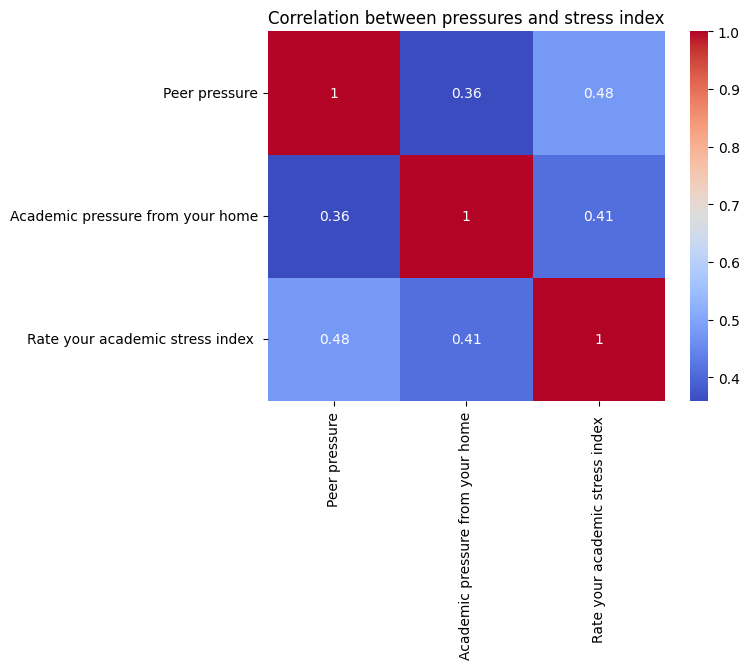

In [14]:
corr = df[['Peer pressure','Academic pressure from your home','Rate your academic stress index ']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation between pressures and stress index")
plt.show()


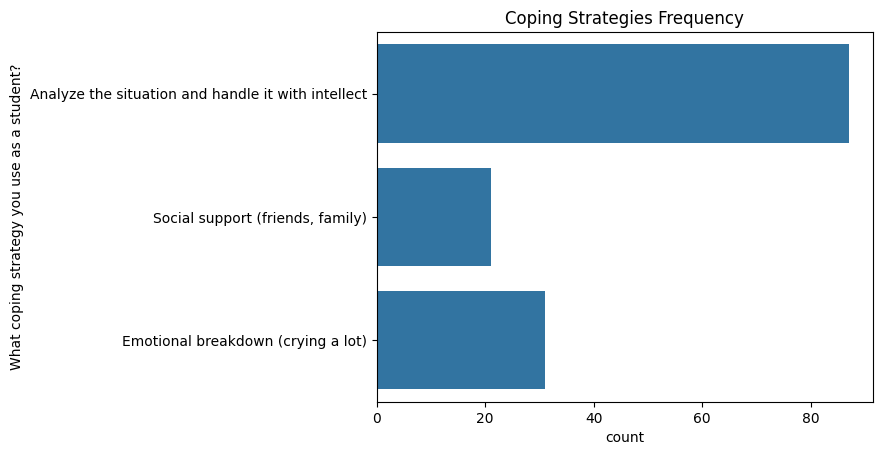

In [15]:
sns.countplot(y="What coping strategy you use as a student?", data=df)
plt.title("Coping Strategies Frequency")
plt.show()


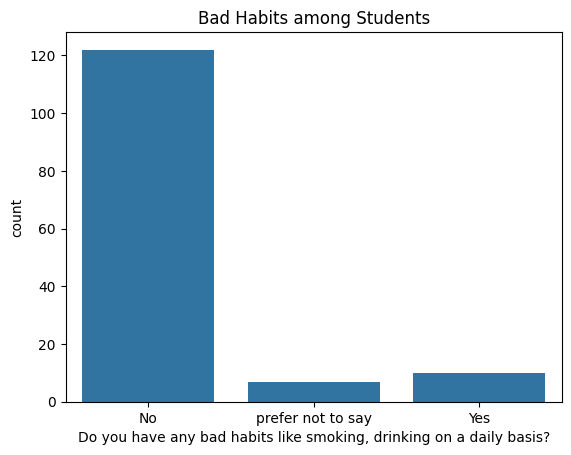

In [16]:
sns.countplot(x="Do you have any bad habits like smoking, drinking on a daily basis?", data=df)
plt.title("Bad Habits among Students")
plt.show()


In [17]:
df['Peer pressure'] = pd.to_numeric(df['Peer pressure'], errors='coerce')
df['Stress Index'] = pd.to_numeric(df['Rate your academic stress index '], errors='coerce')


In [18]:
corr_value = df['Peer pressure'].corr(df['Stress Index'])
print("Correlation coefficient between Peer pressure and Stress Index:", corr_value)


Correlation coefficient between Peer pressure and Stress Index: 0.4765693916986175


In [20]:
from scipy.stats import pearsonr
pearson_corr, p_value = pearsonr(df['Peer pressure'].dropna(), df['Stress Index'].dropna())
print("Pearson correlation:", pearson_corr, "P-value:", p_value)

Pearson correlation: 0.47656939169861723 P-value: 3.0223367354243058e-09


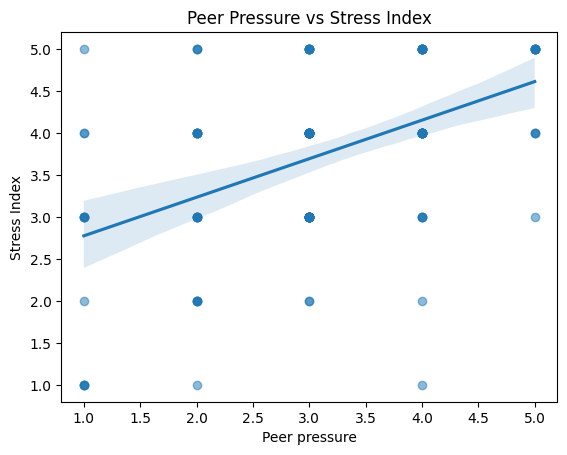

In [21]:
sns.regplot(x="Peer pressure", y="Stress Index", data=df, scatter_kws={'alpha':0.5})
plt.title("Peer Pressure vs Stress Index")
plt.show()


In [22]:
df['Peer pressure'] = pd.to_numeric(df['Peer pressure'], errors='coerce')
df['Academic pressure'] = pd.to_numeric(df['Academic pressure from your home'], errors='coerce')
df['Stress Index'] = pd.to_numeric(df['Rate your academic stress index '], errors='coerce')



In [23]:
corr_matrix = df[['Peer pressure','Academic pressure','Stress Index']].corr()
print(corr_matrix)



                   Peer pressure  Academic pressure  Stress Index
Peer pressure           1.000000           0.358642      0.476569
Academic pressure       0.358642           1.000000      0.409569
Stress Index            0.476569           0.409569      1.000000


In [24]:
peer_corr, peer_p = pearsonr(df['Peer pressure'].dropna(), df['Stress Index'].dropna())
home_corr, home_p = pearsonr(df['Academic pressure'].dropna(), df['Stress Index'].dropna())

print("Peer pressure vs Stress Index:", peer_corr, "P-value:", peer_p)
print("Academic pressure vs Stress Index:", home_corr, "P-value:", home_p)



Peer pressure vs Stress Index: 0.47656939169861723 P-value: 3.0223367354243058e-09
Academic pressure vs Stress Index: 0.4095687435884546 P-value: 5.541649752563323e-07


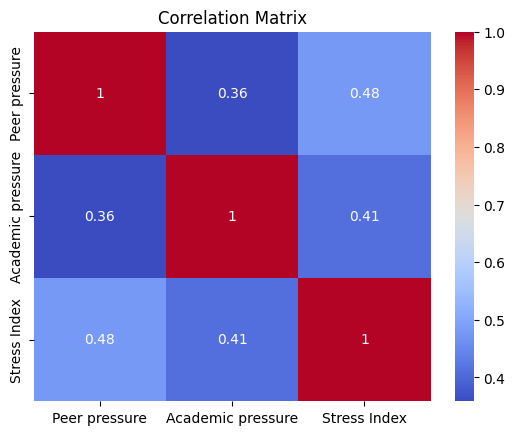

In [25]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()



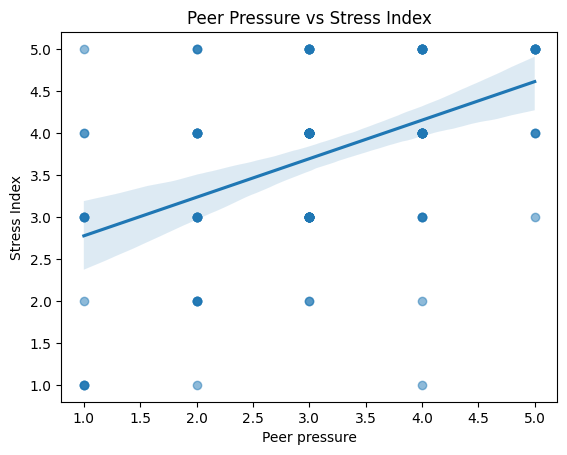

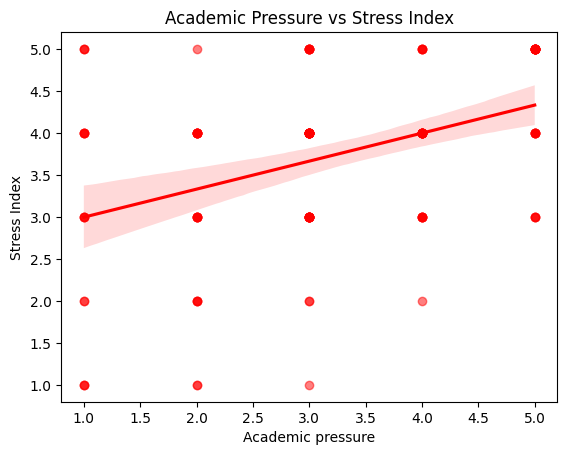

In [26]:
sns.regplot(x="Peer pressure", y="Stress Index", data=df, scatter_kws={'alpha':0.5})
plt.title("Peer Pressure vs Stress Index")
plt.show()

sns.regplot(x="Academic pressure", y="Stress Index", data=df, scatter_kws={'alpha':0.5}, color="red")
plt.title("Academic Pressure vs Stress Index")
plt.show()


In [27]:
df['Peer pressure'] = pd.to_numeric(df['Peer pressure'], errors='coerce')
df['Academic pressure'] = pd.to_numeric(df['Academic pressure from your home'], errors='coerce')
df['Stress Index'] = pd.to_numeric(df['Rate your academic stress index '], errors='coerce')



In [30]:
import statsmodels.api as sm
X = df[['Peer pressure','Academic pressure']]
y = df['Stress Index']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Stress Index   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     28.11
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           6.06e-11
Time:                        21:37:26   Log-Likelihood:                -177.57
No. Observations:                 139   AIC:                             361.1
Df Residuals:                     136   BIC:                             370.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.8989      0.25

In [38]:
df['Peer pressure'] = pd.to_numeric(df['Peer pressure'], errors='coerce')
df['Academic pressure'] = pd.to_numeric(df['Academic pressure from your home'], errors='coerce')
df['Stress Index'] = pd.to_numeric(df['Rate your academic stress index '], errors='coerce')





In [40]:
if 'Study Environment' in df.columns:
    df = pd.get_dummies(df, columns=['Study Environment'], drop_first=True)
else:
    print("The 'Study Environment' column has already been processed or does not exist.")

The 'Study Environment' column has already been processed or does not exist.


In [42]:
study_env_cols = [col for col in df.columns if col.startswith('Study Environment_')]
X = df[['Peer pressure','Academic pressure'] + study_env_cols]
y = df['Stress Index']

In [43]:
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           Stress Index   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     14.50
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           7.28e-10
Time:                        21:44:25   Log-Likelihood:                -176.62
No. Observations:                 139   AIC:                             363.2
Df Residuals:                     134   BIC:                             377.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [44]:
df.to_csv('cleand_stress_level_study.csv', index=False)

In [45]:
from google.colab import files
files.download('cleand_stress_level_study.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>